In [1]:
!pip install ccxt pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.6/142.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 kB 13.9 MB/s eta 0:00:00


In [237]:
import ccxt
import pandas as pd
import time

exchange = ccxt.coinbase()

all_ohlcv = []
since = exchange.parse8601('2025-01-01T00:00:00Z')
end   = exchange.parse8601('2025-12-31T00:00:00Z')

while True:
    batch = exchange.fetch_ohlcv(
        'ETH/USD', '1h',
        since=since, limit=500
    )
    if not batch:
        break
    all_ohlcv += batch
    since = batch[-1][0] + 1
    print(f"Fetched {len(all_ohlcv)} rows...", end='\r')
    time.sleep(0.5)
    if since > end:
        break

df = pd.DataFrame(
    all_ohlcv,
    columns=['timestamp','open','high','low','close','volume']
)
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)
df = df.astype(float)
df = df[~df.index.duplicated()]

print(f"\nTotal rows: {len(df)}")
print(f"From: {df.index[0]}")
print(f"To:   {df.index[-1]}")


Total rows: 8995
From: 2025-01-01 00:00:00
To:   2026-01-10 23:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [238]:
!pip install stable-baselines3 gymnasium ccxt yfinance ta -q

In [239]:
import ta

df['returns']    = df['close'].pct_change()
df['ma10']       = df['close'].rolling(10).mean()
df['ma30']       = df['close'].rolling(30).mean()
df['ma_ratio']   = df['ma10'] / df['ma30']
df['volatility'] = df['returns'].rolling(20).std()
df['rsi']        = ta.momentum.RSIIndicator(df['close'], window=14).rsi()
df['norm_price'] = (df['close'] - df['close'].min()) / (df['close'].max() - df['close'].min())

df.dropna(inplace=True)
print("Features ready:", df.shape)

Features ready: (8966, 12)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [240]:
# In TradingEnv.step() replace action handling with this:
def step(self, action):
    row        = self.df.iloc[self.current_step]
    price      = row['close']
    next_price = self.df.iloc[min(self.current_step+1, self.n-1)]['close']
    price_change = (next_price - price) / price

    reward = 0.0

    if action == 1 and self.position == 0:      # Buy
        self.position    = 1
        self.entry_price = price

    elif action == 2 and self.position == 1:    # Sell to close long
        pnl               = (price - self.entry_price) / self.entry_price
        reward            = pnl
        self.total_profit += pnl
        self.position     = 0

    elif self.position == 1:                    # Holding long
        reward = price_change * 0.1

    # NO short selling at all
    if action != 0:
        reward -= 0.0005

    # Apply unrealized PnL related penalties and stop-loss only if a position is held
    if self.position == 1:
        unrealized_pnl = (price - self.entry_price) / self.entry_price

        # Losing more than 2% penalty
        if unrealized_pnl < -0.02:
            reward -= 0.002

        # Auto stop-loss at -3%
        if unrealized_pnl < -0.03:
            pnl = unrealized_pnl
            reward = pnl # This overrides any previous reward for holding, which is correct for a forced exit
            self.total_profit += pnl
            self.position = 0  # force exit

    self.current_step += 1
    done = self.current_step >= self.n - 1
    return self._get_obs(), reward, done, False, {}

In [241]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

# Train on first 80%
train_df = df.iloc[:int(len(df)*0.8)]
env      = TradingEnv(train_df)

model = PPO(
    "MlpPolicy", env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    ent_coef=0.01,   # ADD THIS — forces exploration
    verbose=1
)
model.learn(total_timesteps=200_000)
base_model = model  # add this line after model.learn()
model.save("ppo_trading")
print("Training done.")


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 1152 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 750        |
|    iterations           | 2          |
|    time_elapsed         | 5          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.01639809 |
|    clip_fraction        | 0.186      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.09      |
|    explained_variance   | -8.19      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.00855   |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.0135    |
|    value_loss           | 0.0054     |

In [242]:
# Confidence-gated evaluation
from stable_baselines3 import PPO
import numpy as np

def predict_with_confidence(model, obs, threshold=0.6):
    # Get action probabilities
    import torch
    obs_tensor = torch.tensor(obs.reshape(1, -1), dtype=torch.float32)
    with torch.no_grad():
        dist = model.policy.get_distribution(obs_tensor)
        probs = dist.distribution.probs.numpy()[0]

    best_prob = probs.max()
    action = probs.argmax()

    if best_prob < threshold:
        return 0, best_prob  # HOLD if not confident
    return int(action), best_prob

# Test with confidence gating
test_df  = df.iloc[int(len(df)*0.8):].reset_index(drop=True)
env      = TradingEnv(test_df)
obs, _   = env.reset()

rewards      = []
actions_log  = []
confidences  = []

for i in range(len(test_df) - 1):
    action, conf = predict_with_confidence(model, obs, threshold=0.6)
    obs, reward, done, _, _ = env.step(action)
    rewards.append(reward)
    actions_log.append(action)
    confidences.append(conf)
    if done:
        break

from collections import Counter
counts = Counter(actions_log)
bh     = test_df['returns'].cumsum().values[:len(rewards)]
ret    = np.array(rewards)

print(f"RL P&L:       {sum(rewards):.4f}")
print(f"B&H P&L:      {bh[-1]:.4f}")
print(f"Avg conf:     {np.mean(confidences):.3f}")
print(f"Trades:       {counts[1]+counts[2]}")
print(f"Forced HOLDs: {counts[0]}")

RL P&L:       -0.2818
B&H P&L:      -0.2340
Avg conf:     0.981
Trades:       27
Forced HOLDs: 1766


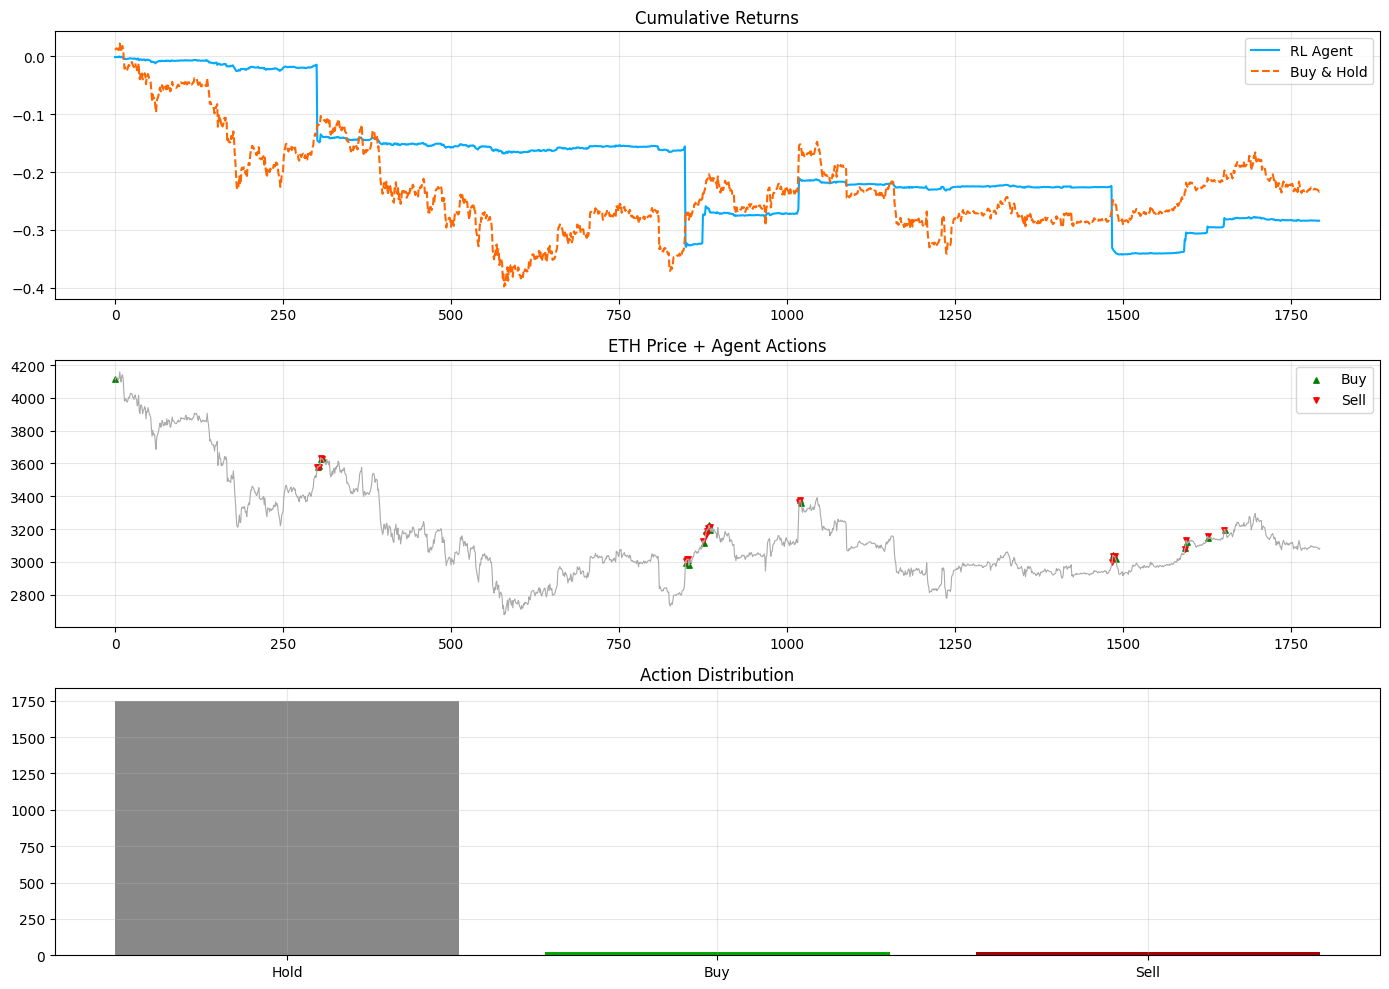

Total RL P&L:     -0.2840
Buy & Hold P&L:   -0.2320
Total trades:     43


In [243]:
import matplotlib.pyplot as plt

test_df  = df.iloc[int(len(df)*0.8):].reset_index(drop=True)
test_env = TradingEnv(test_df)

obs, _      = test_env.reset()
done        = False
rewards     = []
cum_rewards = []
actions_log = []

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = test_env.step(action)
    rewards.append(reward)
    actions_log.append(int(action))
    cum_rewards.append(sum(rewards))

# Buy & Hold baseline
bh_returns = test_df['returns'].cumsum().values

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(cum_rewards, label='RL Agent', color='#00AAFF')
axes[0].plot(bh_returns,  label='Buy & Hold', color='#FF6600', linestyle='--')
axes[0].set_title('Cumulative Returns')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_df['close'].values, color='#AAAAAA', linewidth=0.8)
buy_idx  = [i for i,a in enumerate(actions_log) if a==1]
sell_idx = [i for i,a in enumerate(actions_log) if a==2]
axes[1].scatter(buy_idx,  test_df['close'].iloc[buy_idx],  marker='^', color='green', s=15, label='Buy')
axes[1].scatter(sell_idx, test_df['close'].iloc[sell_idx], marker='v', color='red',   s=15, label='Sell')
axes[1].set_title('ETH Price + Agent Actions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

from collections import Counter
counts = Counter(actions_log)
axes[2].bar(['Hold','Buy','Sell'], [counts[0],counts[1],counts[2]],
            color=['#888888','#00AA00','#AA0000'])
axes[2].set_title('Action Distribution')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total RL P&L:     {sum(rewards):.4f}")
print(f"Buy & Hold P&L:   {bh_returns[-1]:.4f}")
print(f"Total trades:     {counts[1]+counts[2]}")

In [244]:
import numpy as np

ret_arr = np.array(rewards)

sharpe   = (ret_arr.mean() / (ret_arr.std() + 1e-9)) * np.sqrt(252)
cum      = np.cumsum(ret_arr)
peak     = np.maximum.accumulate(cum)
drawdown = (cum - peak)
max_dd   = drawdown.min()

print(f"Sharpe Ratio:    {sharpe:.3f}")
print(f"Max Drawdown:    {max_dd:.4f}")
print(f"Win Rate:        {(ret_arr > 0).mean()*100:.1f}%")

Sharpe Ratio:    -0.415
Max Drawdown:    -0.3420
Win Rate:        50.2%


In [245]:
print(f"Total df rows:  {len(df)}")
print(f"Train rows:     {len(train_df)}")
print(f"Test rows:      {len(test_df)}")

Total df rows:  8966
Train rows:     7172
Test rows:      1794


In [246]:
print(f"Train: {df.index[0]} to {df.index[int(len(df)*0.8)]}")
print(f"Test:  {df.index[int(len(df)*0.8)]} to {df.index[-1]}")

Train: 2025-01-02 05:00:00 to 2025-10-28 06:00:00
Test:  2025-10-28 06:00:00 to 2026-01-10 23:00:00


In [247]:
!pip install hmmlearn -q

In [248]:
import numpy as np
from scipy import stats

# New features
df['price_momentum'] = df['close'].pct_change(20)
df['ma_slope']       = df['ma10'].diff(5) / df['ma10'].shift(5)
df['trend_dir']      = (df['ma10'] - df['ma30']) / df['ma30']

# Thresholds
vol_high = df['volatility'].quantile(0.66)

def classify(row):
    if row['volatility'] > vol_high:
        return 'volatile'
    elif abs(row['price_momentum']) > 0.03 or abs(row['ma_slope']) > 0.005:
        return 'trending'
    else:
        return 'ranging'

df['regime_label'] = df.apply(classify, axis=1)
print("Before smoothing:\n", df['regime_label'].value_counts())

# Smooth — rolling mode over 48 candles
df['regime_code'] = df['regime_label'].map({'ranging':0,'trending':1,'volatile':2})
# Just change this one line in Cell 8
df['regime_code'] = df['regime_code'].rolling(168, min_periods=1).apply(
    lambda x: stats.mode(x, keepdims=True)[0][0]
).astype(int)
df['regime_label'] = df['regime_code'].map({0:'ranging',1:'trending',2:'volatile'})

print("\nAfter smoothing:\n", df['regime_label'].value_counts())

Before smoothing:
 regime_label
ranging     3215
volatile    3049
trending    2702
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



After smoothing:
 regime_label
ranging     4057
volatile    3258
trending    1651
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


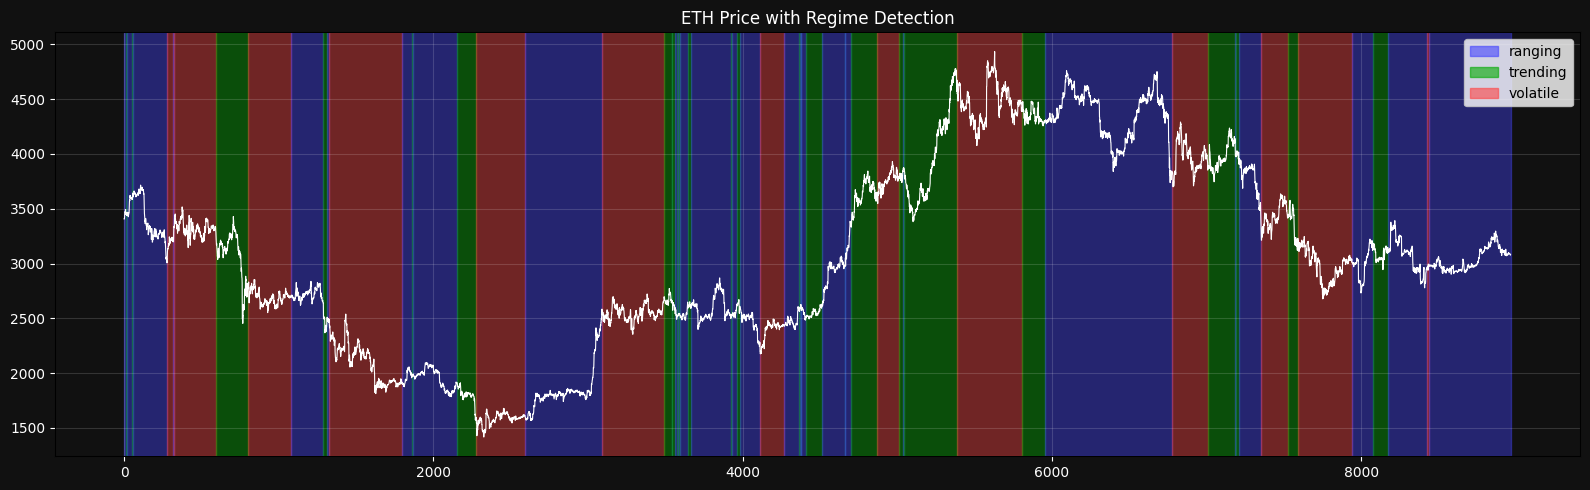

In [249]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colors   = {'ranging': '#4444FF', 'trending': '#00AA00', 'volatile': '#FF4444'}
fig, ax  = plt.subplots(figsize=(16, 5))
plot_df  = df.reset_index(drop=True)

ax.plot(plot_df['close'].values, color='white', linewidth=0.8, zorder=2)

regime_arr = plot_df['regime_label'].values
i = 0
while i < len(regime_arr):
    regime = regime_arr[i]
    j = i
    while j < len(regime_arr) and regime_arr[j] == regime:
        j += 1
    ax.axvspan(i, j, alpha=0.4, color=colors.get(regime, 'grey'), zorder=0)
    i = j

patches = [mpatches.Patch(color=v, label=k, alpha=0.6) for k,v in colors.items()]
ax.legend(handles=patches, loc='upper right')
ax.set_facecolor('#111111')
fig.patch.set_facecolor('#111111')
ax.set_title('ETH Price with Regime Detection', color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.15, color='white')
plt.tight_layout()
plt.show()